## Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load Dataset

In [ ]:
from datasets import load_dataset
emotion_dataset = load_dataset("dair-ai/emotion")

train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
label_names = emotion_dataset['train'].features['label'].names

In [ ]:
df_train = pd.DataFrame(
    {
        'text': train_text,
        'label': [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text': test_text,
        'label': [label_names[i] for i in test_label]
    }
)

In [ ]:
df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


## Ploting

In [ ]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

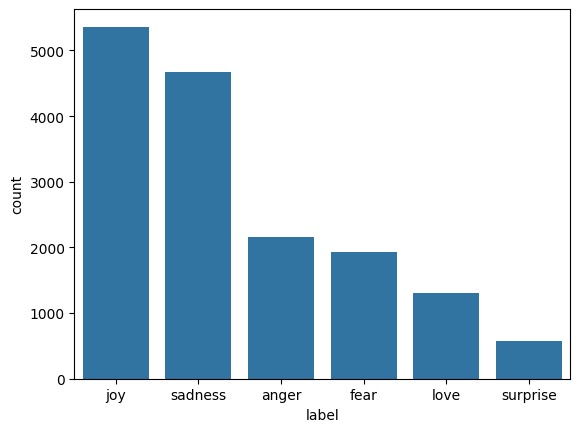

In [ ]:
sns.countplot(x='label', data=df_train, order = df_train['label'].value_counts().index)


## Data Preprocessing - NLP

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000


tokenizer = Tokenizer(num_words = max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])


train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])


padded_train_sequence = pad_sequences(train_sequence, maxlen=50, padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequence, maxlen=50, padding='post', truncating='post')


train_labels = np.array(train_label)
test_labels = np.array(test_label)


num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Max sequence length: {padded_train_sequence.shape[1]}")

Vocabulary size: 15213
Max sequence length: 50


## Training Utilites

In [ ]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_labels),
    y = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## Model - 1

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GRU, SimpleRNN


rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])


rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)

print(f'RNN Loss: {rnn_loss}, RNN Accuracy: {rnn_accuracy}')

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1882 - loss: 1.6860 - val_accuracy: 0.1040 - val_loss: 1.8512
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2001 - loss: 1.6706 - val_accuracy: 0.1315 - val_loss: 1.8033
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.2154 - loss: 1.6503 - val_accuracy: 0.1225 - val_loss: 1.8636
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1040 - loss: 1.8512
RNN Loss: 1.8511790037155151, RNN Accuracy: 0.10400000214576721


## Model - 2 LSTM

In [ ]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.1636 - loss: 1.7947 - val_accuracy: 0.0515 - val_loss: 1.8126
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1662 - loss: 1.7938 - val_accuracy: 0.0330 - val_loss: 1.8071
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1831 - loss: 1.7933 - val_accuracy: 0.1395 - val_loss: 1.7928
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0515 - loss: 1.8126
LSTM Loss: 1.8126360177993774
LSTM Accuracy: 0.051500000059604645


## Model - 3 GRU

In [ ]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.1557 - loss: 1.7973 - val_accuracy: 0.0435 - val_loss: 1.7891
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.1416 - loss: 1.7949 - val_accuracy: 0.1120 - val_loss: 1.7785
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1484 - loss: 1.7946 - val_accuracy: 0.2890 - val_loss: 1.7974
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0435 - loss: 1.7891
GRU Loss: 1.7891191244125366
GRU Accuracy: 0.04349999874830246


In [ ]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Loss' : [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy' : [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Test Accuracy', ascending=False)

result_df

,Model,Loss,Test Accuracy
0,RNN,1.851179,0.1040
1,LSTM,1.812636,0.0515
2,GRU,1.789119,0.0435


## Advanced Bidirectional GRU

In [ ]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300, input_length = 50),
    Bidirectional(GRU(units=128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(units=64)),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

BiGRU.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.5904 - loss: 1.0372 - val_accuracy: 0.8835 - val_loss: 0.3570
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9156 - loss: 0.2365 - val_accuracy: 0.9200 - val_loss: 0.2344
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.9442 - loss: 0.1547 - val_accuracy: 0.9155 - val_loss: 0.2299


In [ ]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8835 - loss: 0.3570
BiGRU Loss: 0.35697829723358154
BiGRU Accuracy: 0.8834999799728394


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


<Axes: >

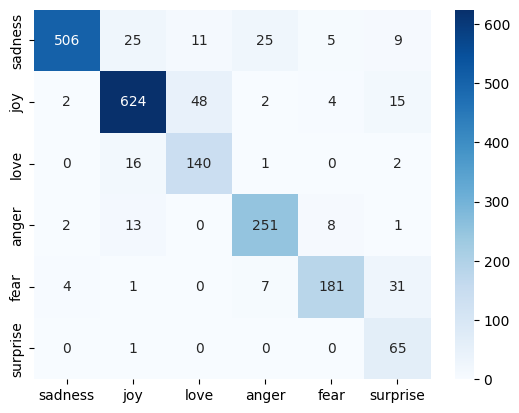

In [ ]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)

## Final Predictions

In [ ]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]


sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')


sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


## Save Model and Tokenizer

In [ ]:
import os
import pickle

model_dir = 'Artifact'
os.makedirs(model_dir, exist_ok=True)


BiGRU.save(os.path.join(model_dir, 'BiGRU_Model.keras'))

with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
    pickle.dump(tokenizer, file)